# Employee Attrition Prediction — Phase 1: EDA & Statistical Analysis

**Business problem:** Voluntary employee attrition is costly — replacing an employee is commonly
estimated (across various HR/SHRM industry studies) to cost anywhere from a few months' to a full
year's salary once recruiting, onboarding, and lost productivity are factored in. If HR can flag
employees who are statistically likely to leave, the business can intervene early (retention
conversations, compensation review, role changes) instead of reacting after a resignation letter.

**Dataset:** IBM HR Analytics Employee Attrition & Performance — a publicly available, IBM-published
dataset of 1,470 employees with 35 attributes (demographics, compensation, satisfaction survey scores,
role/tenure information) and a binary `Attrition` label (`Yes`/`No`).

**Goal of this notebook:** Understand the data, quantify which features actually separate
leavers from stayers (not just visually — statistically), and produce a clean dataset for the
feature engineering / modeling notebook that follows.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)


## 1. Load the data

In [5]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 2. Structural overview

Check dtypes, missing values, and columns that carry no information (constant across all rows).

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")


Missing values per column:
None — dataset is complete.


In [8]:
# Columns that are constant (zero variance) add no predictive value and should be dropped later
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns (candidates to drop):", constant_cols)
for c in constant_cols:
    print(f"  {c}: {df[c].unique()}")

# EmployeeNumber is a unique identifier, not a feature
print("\nEmployeeNumber is unique per row:", df['EmployeeNumber'].is_unique)


Constant columns (candidates to drop): ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: [1]
  Over18: <StringArray>
['Y']
Length: 1, dtype: str
  StandardHours: [80]

EmployeeNumber is unique per row: True


## 3. Target variable: `Attrition`

This is the single most important number in the whole analysis — it tells us how imbalanced the
problem is, which will drive both the evaluation metrics we choose later (accuracy is **not**
appropriate here) and the resampling strategy.

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


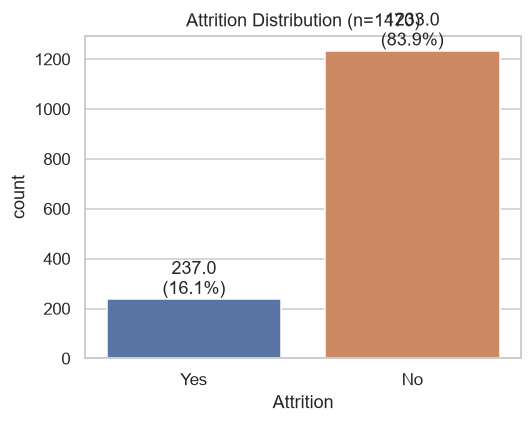

In [11]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print(attrition_counts)
print()
print(attrition_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette=['#4C72B0', '#DD8452'], legend=False, ax=ax)
ax.set_title(f"Attrition Distribution (n={len(df)})")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig("../reports/figures/01_attrition_distribution.png")
plt.show()


**Takeaway:** Attrition is imbalanced (roughly 1 in 6 employees leave). This means:
- A model that just predicts "No" for everyone would already be ~84% "accurate" — useless for the business.
- We need to evaluate on **precision, recall, F1, and ROC-AUC**, not accuracy, in the modeling notebook.
- We'll likely need class-weighting or resampling (e.g. SMOTE) during modeling.

## 4. Numeric features vs. Attrition

Visual comparison of key numeric features split by attrition status.

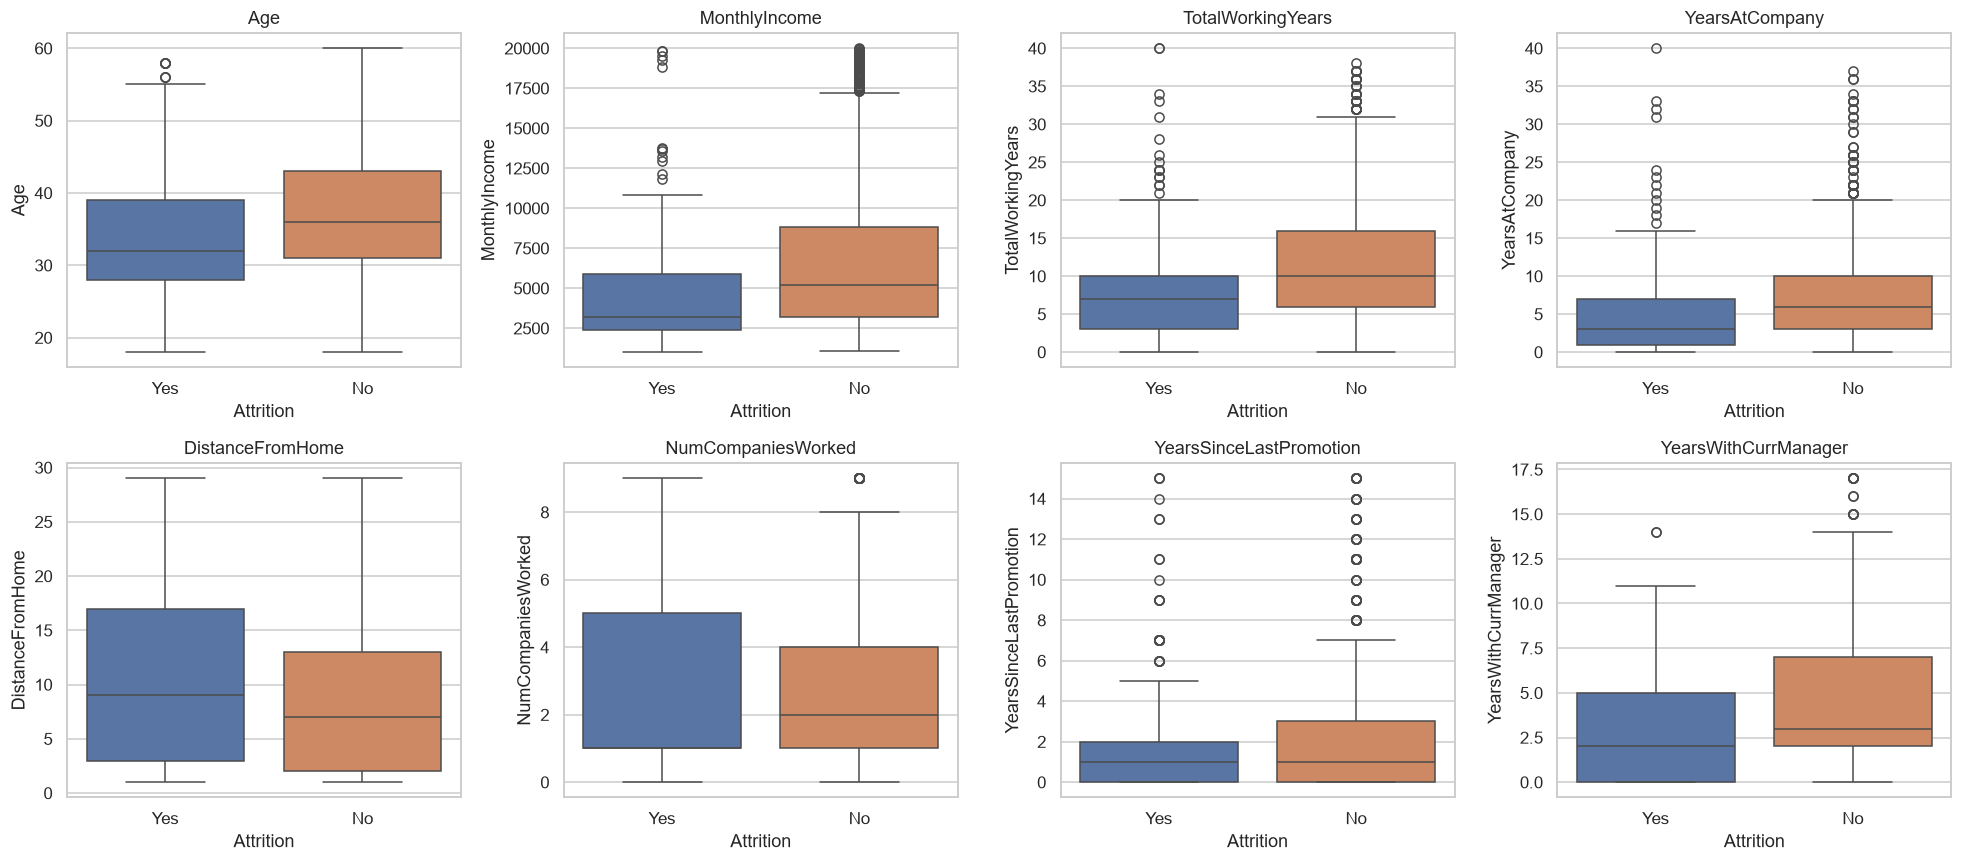

In [12]:
numeric_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                     'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion',
                     'YearsWithCurrManager']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(numeric_features):
    sns.boxplot(data=df, x='Attrition', y=feat, hue='Attrition',
                palette=['#4C72B0', '#DD8452'], legend=False, ax=axes[i])
    axes[i].set_title(feat)
plt.tight_layout()
plt.savefig("../reports/figures/02_numeric_boxplots.png")
plt.show()


## 5. Categorical features vs. Attrition

Attrition *rate* (%) within each category — this normalizes for group size, which a raw count plot would not.

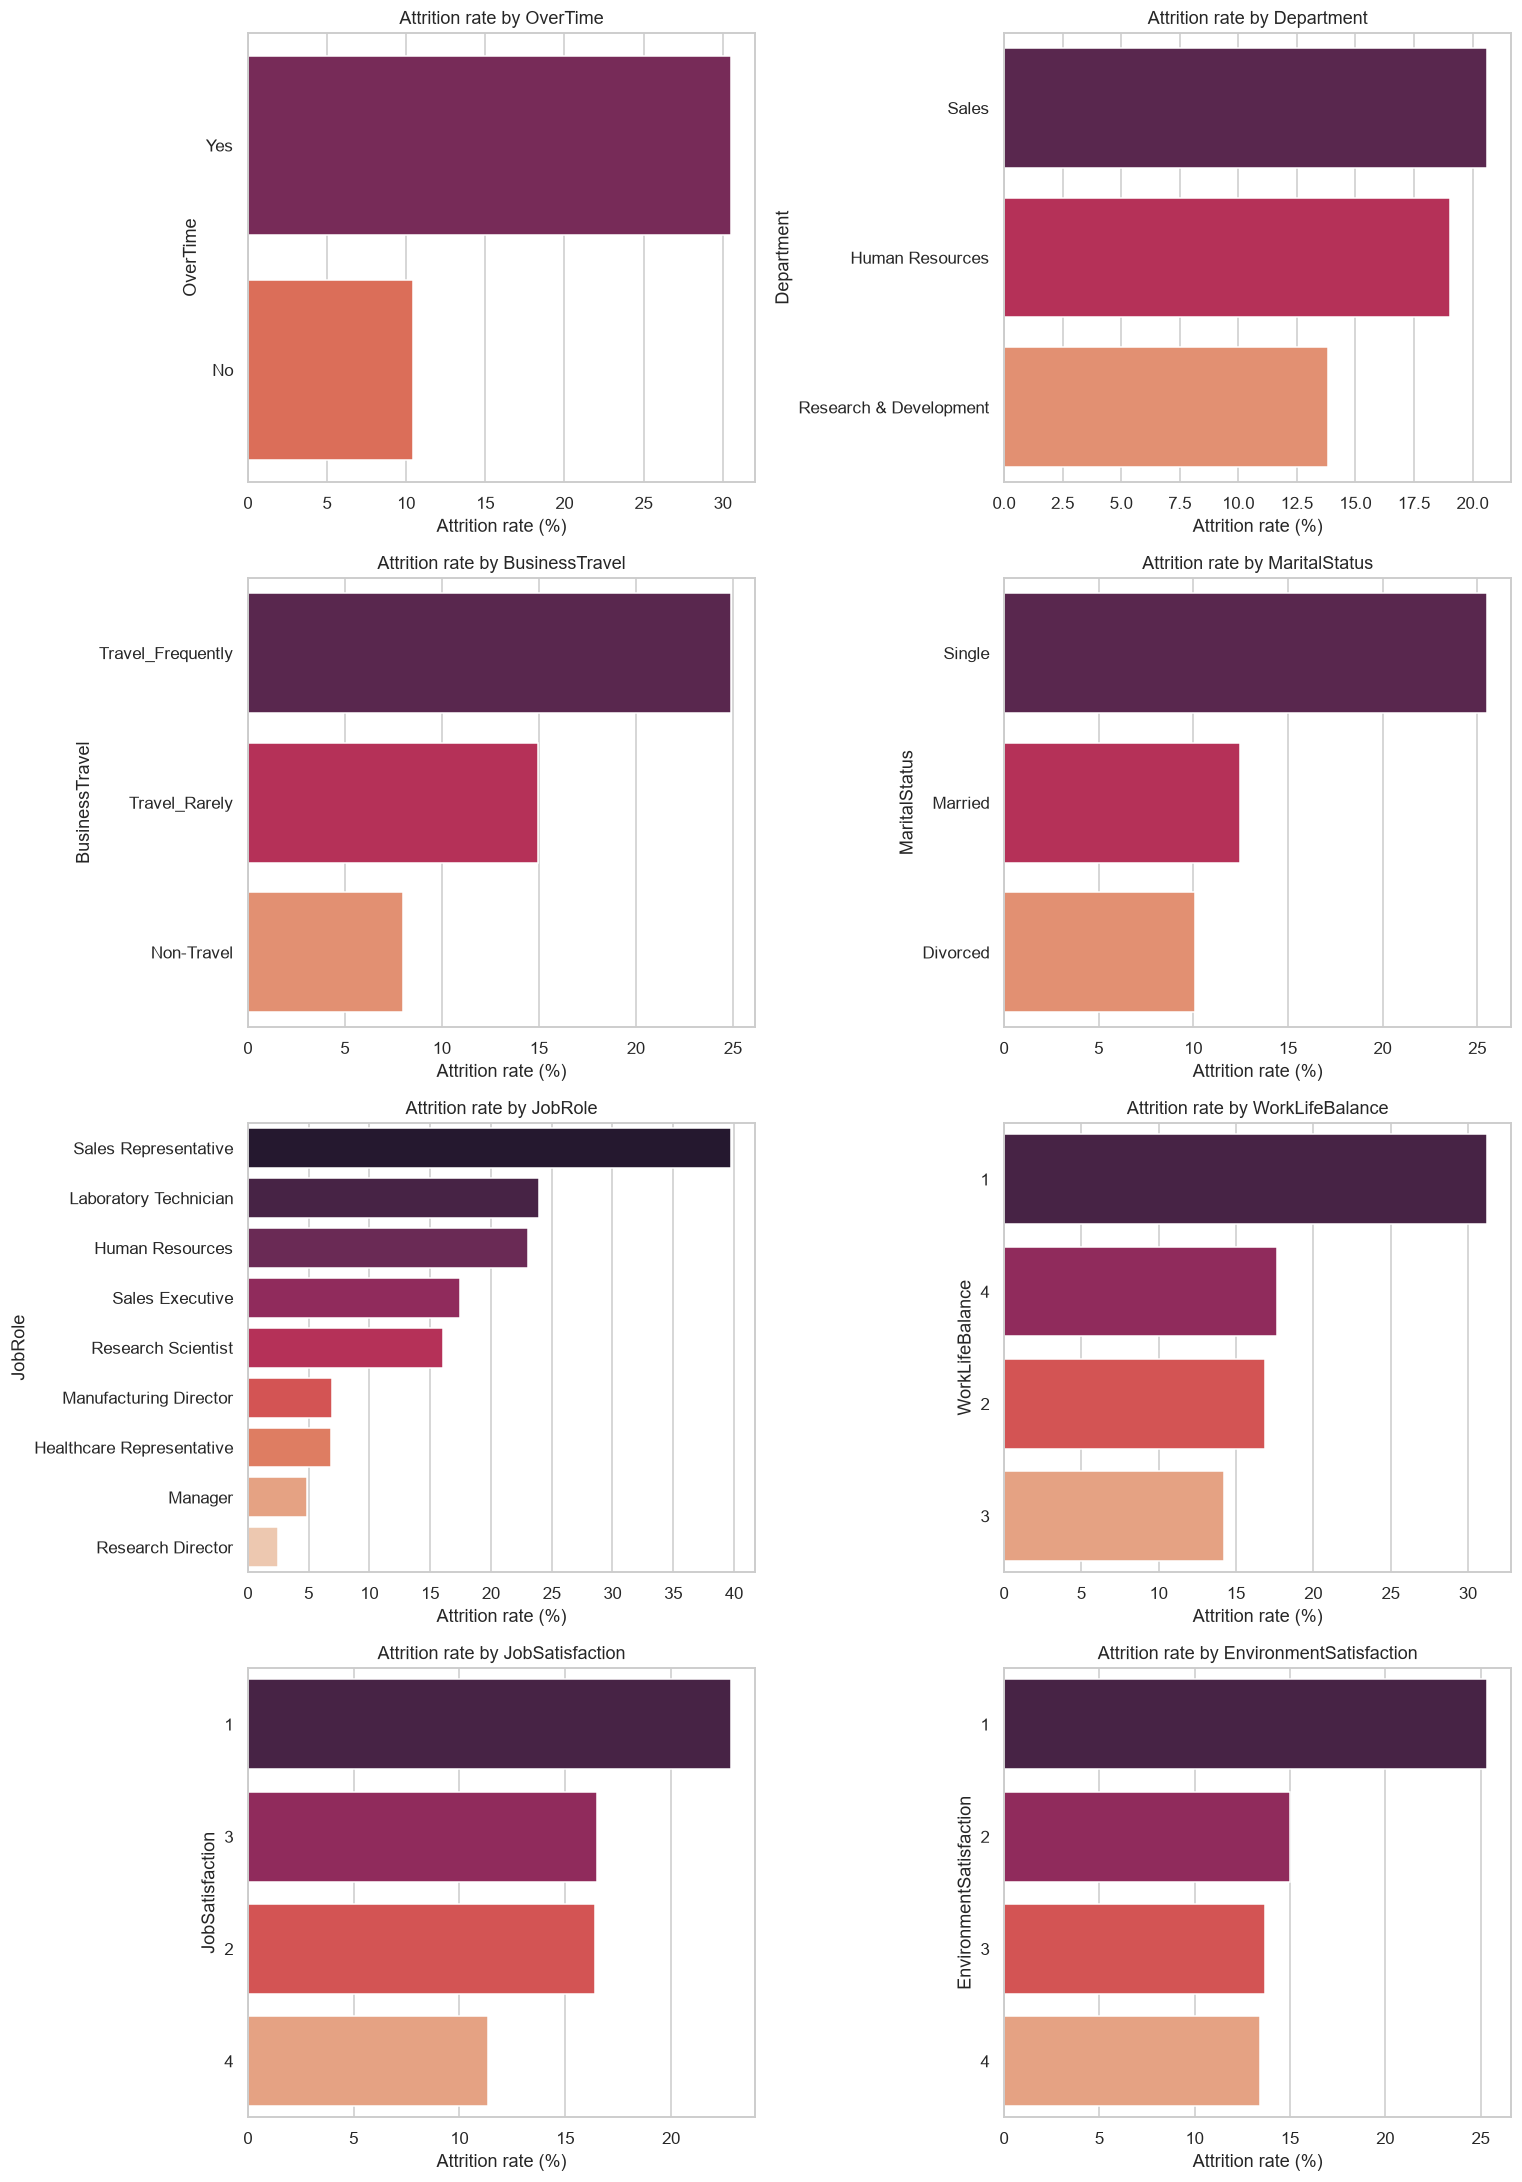

In [13]:
categorical_features = ['OverTime', 'Department', 'BusinessTravel', 'MaritalStatus',
                        'JobRole', 'WorkLifeBalance', 'JobSatisfaction', 'EnvironmentSatisfaction']

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()
for i, feat in enumerate(categorical_features):
    rate = (df.groupby(feat)['Attrition']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .sort_values(ascending=False))
    sns.barplot(x=rate.values, y=rate.index.astype(str), hue=rate.index.astype(str),
                palette='rocket', legend=False, ax=axes[i])
    axes[i].set_title(f"Attrition rate by {feat}")
    axes[i].set_xlabel("Attrition rate (%)")
plt.tight_layout()
plt.savefig("../reports/figures/03_categorical_attrition_rates.png")
plt.show()


## 6. Correlation among numeric features

Useful for spotting multicollinearity before modeling (e.g. `JobLevel`, `MonthlyIncome`, and `TotalWorkingYears` are often highly correlated with each other).

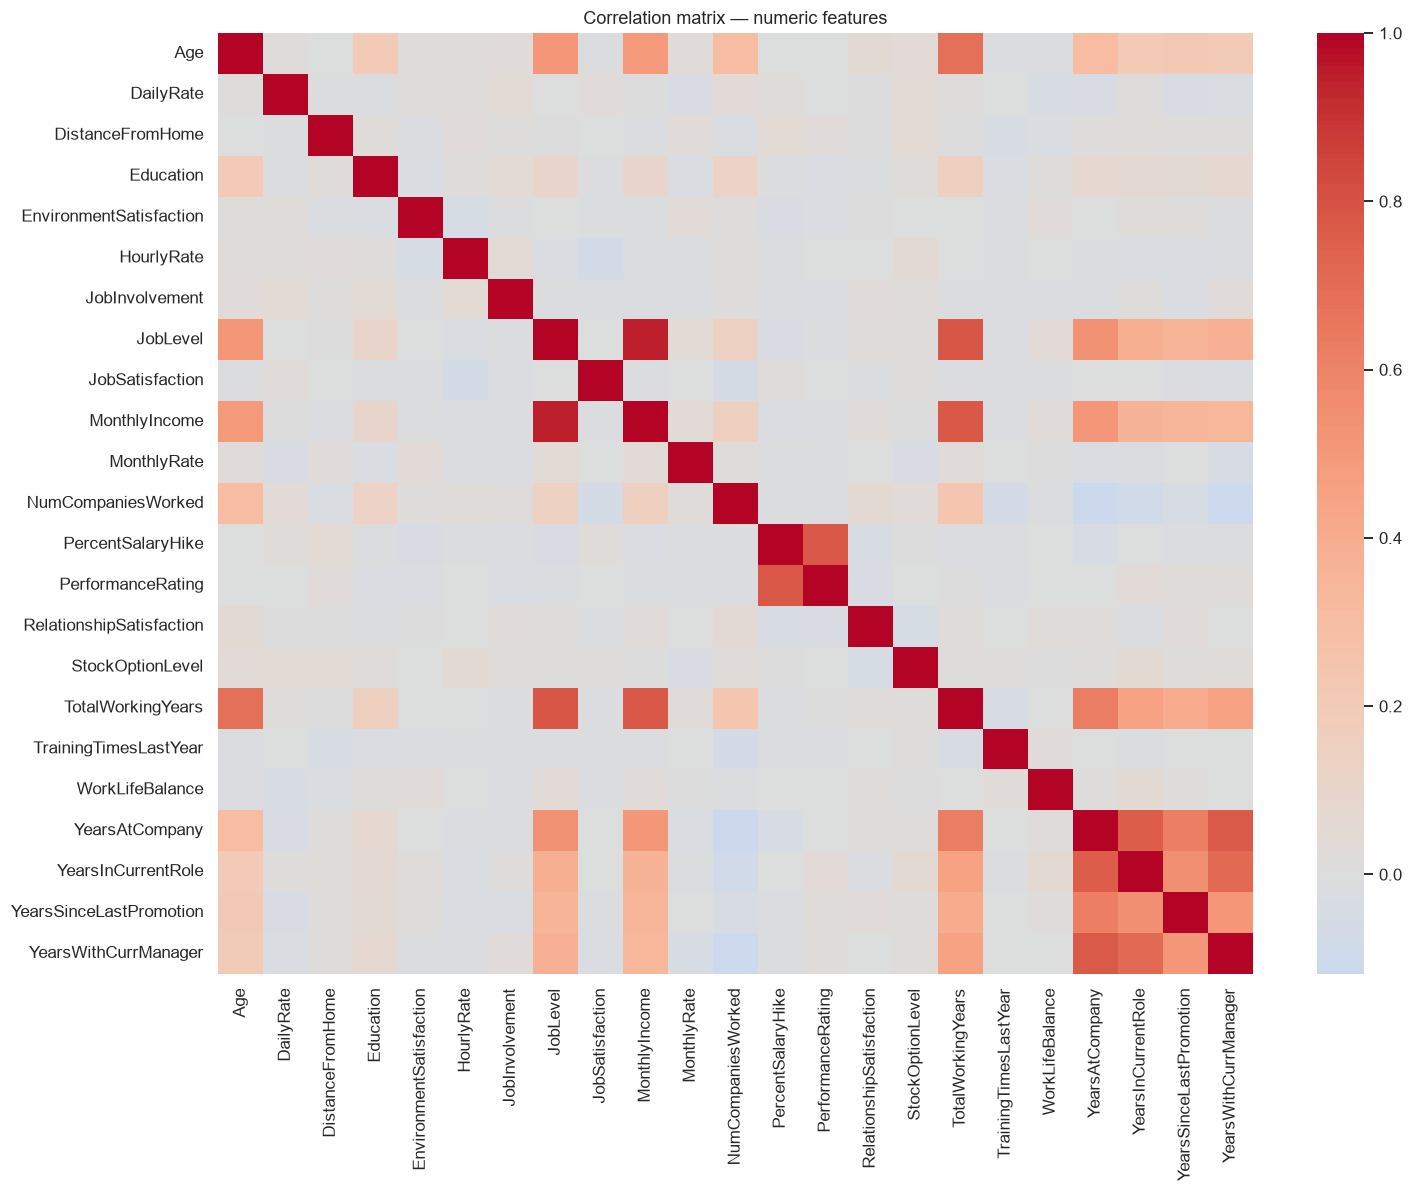

In [14]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=constant_cols + ['EmployeeNumber'], errors='ignore')

plt.figure(figsize=(14, 11))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.savefig("../reports/figures/04_correlation_heatmap.png")
plt.show()


## 7. Statistical significance — ANOVA (numeric features)

Visual differences in box plots can be misleading with small effect sizes. We run a one-way
**ANOVA** for every numeric feature, testing whether its mean differs significantly between the
"Yes" and "No" attrition groups. A low p-value (< 0.05) means the feature is statistically
associated with attrition.

In [15]:
anova_results = []
num_cols_for_test = [c for c in num_df.columns]

for col in num_cols_for_test:
    group_yes = df.loc[df['Attrition'] == 'Yes', col]
    group_no = df.loc[df['Attrition'] == 'No', col]
    f_stat, p_val = stats.f_oneway(group_yes, group_no)
    anova_results.append({'feature': col, 'F_statistic': f_stat, 'p_value': p_val})

anova_df = pd.DataFrame(anova_results).sort_values('p_value')
anova_df['significant_at_0.05'] = anova_df['p_value'] < 0.05
anova_df


,feature,F_statistic,p_value,significant_at_0.05
16,TotalWorkingYears,44.252491,4.061878e-11,True
7,JobLevel,43.215344,6.795385e-11,True
20,YearsInCurrentRole,38.838303,6.003186e-10,True
9,MonthlyIncome,38.488819,7.147364e-10,True
0,Age,38.175887,8.356308e-10,True
22,YearsWithCurrManager,36.712311,1.736987e-09,True
15,StockOptionLevel,28.140501,1.301015e-07,True
19,YearsAtCompany,27.001624,2.318872e-07,True
6,JobInvolvement,25.241985,5.677065e-07,True
8,JobSatisfaction,15.890004,7.043067e-05,True


## 8. Statistical significance — Chi-square (categorical features)

For categorical features, ANOVA doesn't apply — instead we use a **Chi-square test of
independence** on the contingency table of feature vs. Attrition.

In [16]:
cat_cols = df.select_dtypes(exclude='number').columns.drop('Attrition')

chi2_results = []
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['Attrition'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({'feature': col, 'chi2_statistic': chi2, 'p_value': p_val})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df['significant_at_0.05'] = chi2_df['p_value'] < 0.05
chi2_df


,feature,chi2_statistic,p_value,significant_at_0.05
7,OverTime,87.564294,8.158424e-21,True
4,JobRole,86.190254,2.752482e-15,True
5,MaritalStatus,46.163677,9.455511e-11,True
0,BusinessTravel,24.182414,5.608614e-06,True
1,Department,10.796007,4.525607e-03,True
2,EducationField,16.024674,6.773980e-03,True
3,Gender,1.116967,2.905724e-01,False
6,Over18,0.000000,1.000000e+00,False


## 9. Combined view: statistically significant drivers of attrition

In [17]:
top_numeric = anova_df[anova_df['significant_at_0.05']].head(8)['feature'].tolist()
top_categorical = chi2_df[chi2_df['significant_at_0.05']].head(8)['feature'].tolist()

print("Statistically significant numeric drivers (ANOVA, p < 0.05):")
print(top_numeric)
print()
print("Statistically significant categorical drivers (Chi-square, p < 0.05):")
print(top_categorical)


Statistically significant numeric drivers (ANOVA, p < 0.05):
['TotalWorkingYears', 'JobLevel', 'YearsInCurrentRole', 'MonthlyIncome', 'Age', 'YearsWithCurrManager', 'StockOptionLevel', 'YearsAtCompany']

Statistically significant categorical drivers (Chi-square, p < 0.05):
['OverTime', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'Department', 'EducationField']


**Key findings from this run:**

- Overall attrition rate is **16.1%** (237 of 1,470 employees) — confirms the imbalance noted in Section 3.
- **`OverTime` is the single strongest categorical driver** (chi2 p ≈ 8e-21): employees who work
  overtime leave at **30.5%**, vs. **10.4%** for those who don't — roughly a 3x difference.
- **`JobRole` matters a lot**: Sales Representatives leave at **39.8%**, while Research Directors
  and Managers sit under 5%. This isn't just "tenure" — it likely reflects role-specific stress,
  compensation structure, or career ceiling.
- **`MaritalStatus`**: Single employees leave at **25.5%** vs. **12.5%** for married — consistent
  with single employees often having fewer location/financial ties to a specific employer.
- On the numeric side, **`TotalWorkingYears`, `JobLevel`, `YearsInCurrentRole`, `MonthlyIncome`,
  and `Age`** are the strongest drivers (all p < 1e-9) — broadly, less senior / earlier-career
  employees are more likely to leave.
- **Not significant** in this dataset: `Gender`, `PerformanceRating`, `Education`, `MonthlyRate`,
  `PercentSalaryHike`, `HourlyRate` — these are candidates to drop, which keeps the eventual model
  simpler and easier to justify to HR stakeholders.

**Caveat:** statistical significance tells us a relationship is real and not due to chance in this
sample — it does **not** tell us how strong or actionable the effect is on its own (e.g. p-values
don't account for correlation between features, like `JobLevel` and `MonthlyIncome` moving together).
We'll quantify actual predictive strength with feature importance / SHAP in the modeling notebook.

## 10. Save a cleaned dataset for the next notebook

In [18]:
df_clean = df.drop(columns=constant_cols, errors='ignore')
df_clean.to_csv("../data/processed/attrition_clean.csv", index=False)
print(f"Saved cleaned dataset: {df_clean.shape} -> ../data/processed/attrition_clean.csv")
print(f"Dropped columns: {constant_cols}")


Saved cleaned dataset: (1470, 32) -> ../data/processed/attrition_clean.csv
Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours']


---
### Next notebook: `02_feature_engineering_modeling.ipynb`
- Encode categorical variables
- Address class imbalance (SMOTE / class weights)
- Train & compare Logistic Regression, Random Forest, XGBoost
- Evaluate with precision/recall/F1/ROC-AUC (justified by the business cost framing above)
- SHAP explainability for the final model
